# 예측 유지보수 모델 개발 과정
이 노트북은 설비 고장 예측 모델을 개발하고 실험하는 과정을 상세히 기록합니다.
## 목차
1. **라이브러리 임포트**: 필요한 Python 라이브러리를 불러옵니다.
2. **데이터 로드 및 탐색 (EDA)**: 데이터셋의 기본 정보를 확인하고, 고장 분포를 시각화합니다.
3. **데이터 전처리**: 모델링에 적합하도록 데이터를 가공합니다.
4. **기본 모델 훈련 및 평가**: `RandomForestClassifier`를 사용하여 기본 모델을 구축하고 성능을 평가합니다.
5. **성능 지표(Metric)에 대한 고찰**: 특히 `Recall`의 중요성에 대해 분석합니다.
6. **모델 성능 개선**: 하이퍼파라미터 튜닝을 통해 모델 성능을 최적화합니다.
7. **피처 중요도 분석**: 어떤 변수가 고장 예측에 큰 영향을 미치는지 확인합니다.
8. **결론 및 향후 방향**: 실험 결과를 요약하고, 다른 모델과의 비교 등 추가 개선 방향을 제시합니다.

## 1. 라이브러리 임포트

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')
print("라이브러리 로드 완료")

라이브러리 로드 완료


## 2. 데이터 로드 및 탐색 (EDA)

In [5]:
df = pd.read_csv('../data/ai4i2020.csv')
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


데이터의 타입과 결측치를 확인합니다.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

### 고장 분포 확인
타겟 변수인 'Machine failure'의 분포를 확인합니다. 데이터 불균형이 심한 것을 볼 수 있습니다.

고장 데이터 분포:
 Machine failure
0    9661
1     339
Name: count, dtype: int64

전체 데이터 중 고장 비율: 3.39%


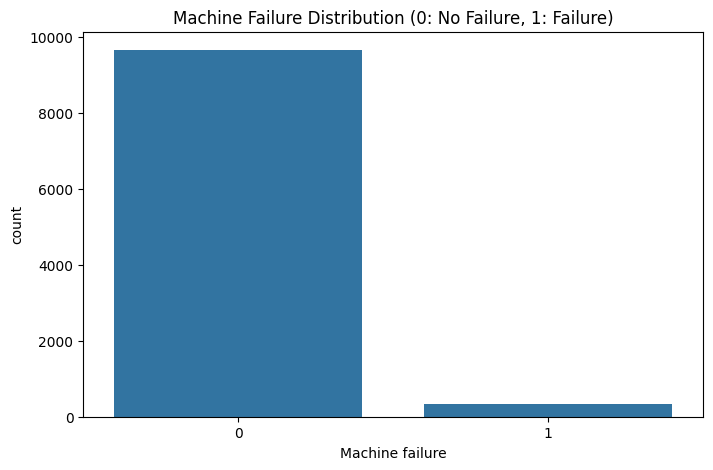

In [7]:
failure_counts = df['Machine failure'].value_counts()
print("고장 데이터 분포:\n", failure_counts)
failure_rate = (failure_counts.get(1, 0) / len(df)) * 100
print(f"\n전체 데이터 중 고장 비율: {failure_rate:.2f}%")

plt.figure(figsize=(8, 5))
sns.countplot(x='Machine failure', data=df)
plt.title('Machine Failure Distribution (0: No Failure, 1: Failure)')
plt.show()

### 주요 센서 데이터와 고장 관계 시각화

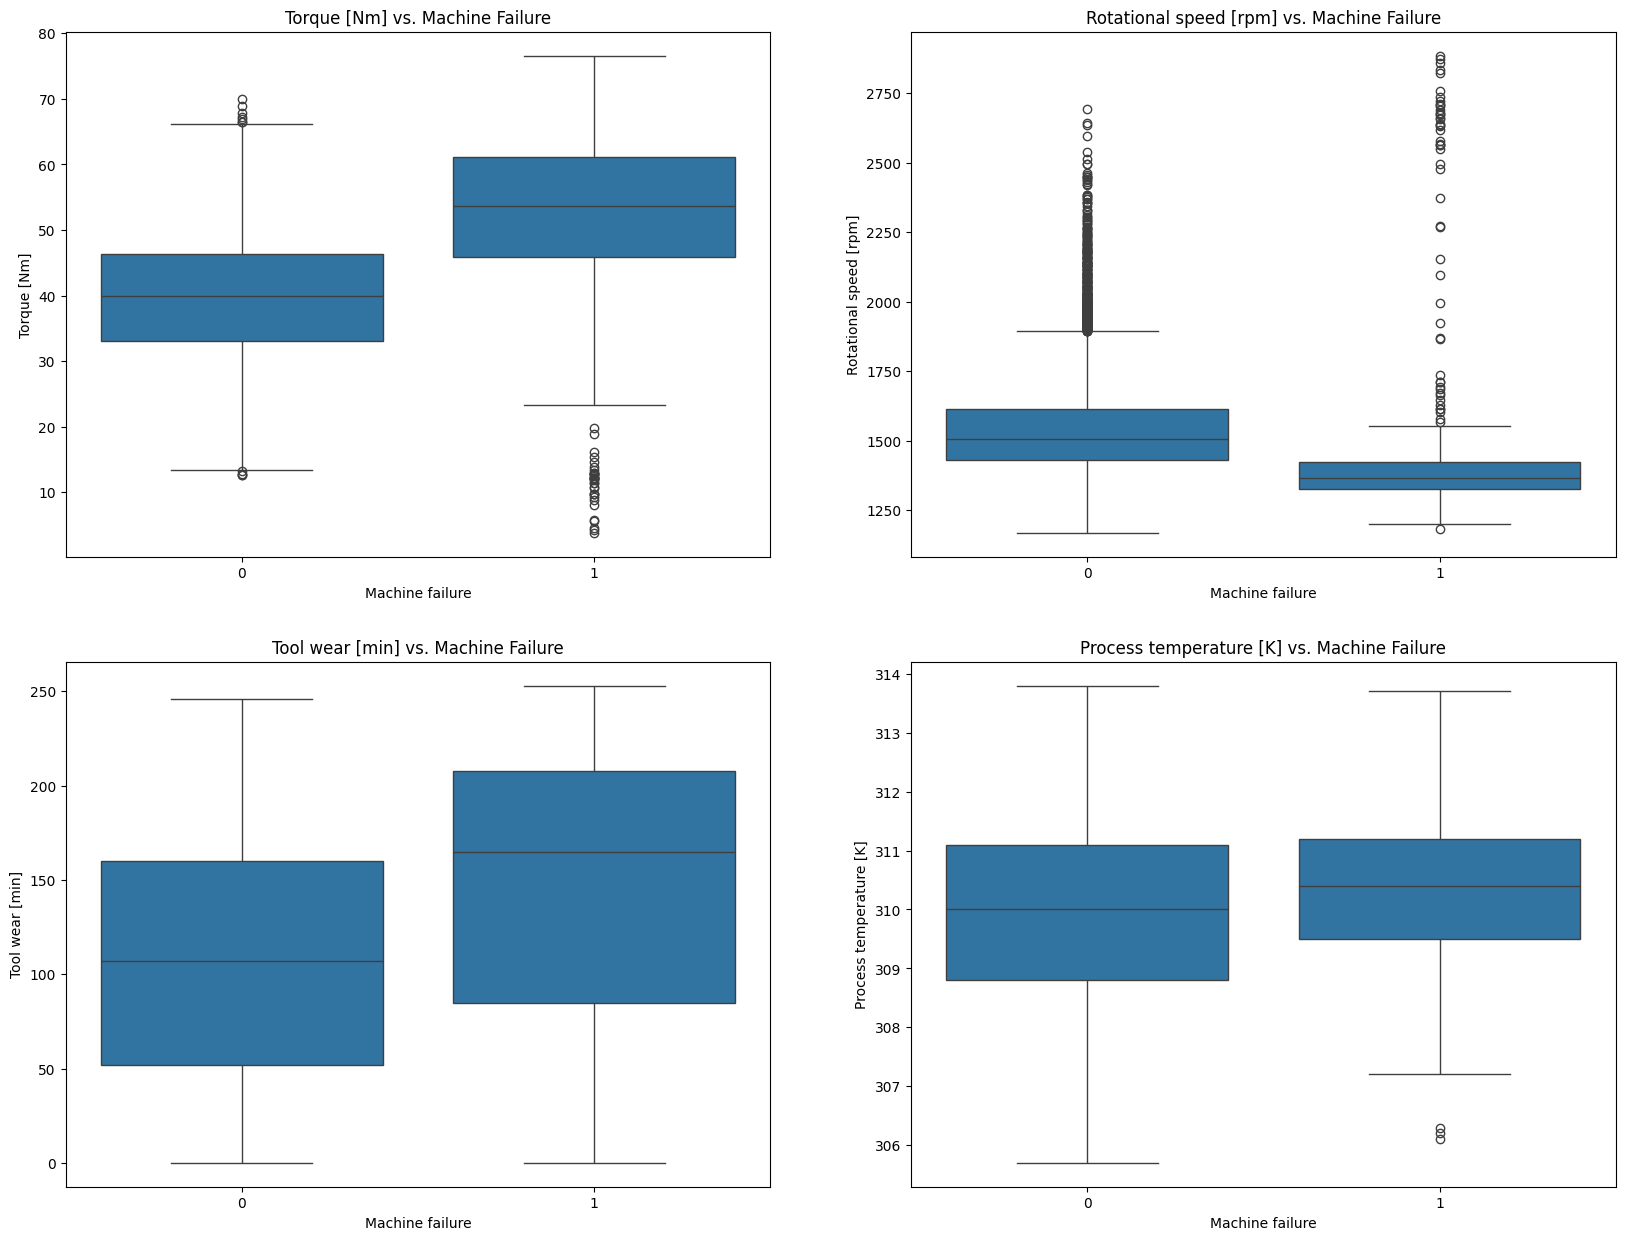

In [8]:
features_to_plot = ['Torque [Nm]', 'Rotational speed [rpm]', 'Tool wear [min]', 'Process temperature [K]']
plt.figure(figsize=(20, 15))
for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x='Machine failure', y=feature, data=df)
    plt.title(f'{feature} vs. Machine Failure')
plt.show()

## 3. 데이터 전처리

In [9]:
df_model = df.drop(['UDI', 'Product ID'], axis=1)
df_model = pd.get_dummies(df_model, columns=['Type'], drop_first=True)

X = df_model.drop('Machine failure', axis=1)
y = df_model['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"학습 데이터 개수: {len(X_train)}")
print(f"테스트 데이터 개수: {len(X_test)}")

학습 데이터 개수: 8000
테스트 데이터 개수: 2000


## 4. 기본 모델 훈련 및 평가
데이터 불균형을 고려하여 `class_weight='balanced'` 옵션을 사용합니다.

In [10]:
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"모델 예측 정확도: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("성능 상세 리포트:\n", classification_report(y_test, y_pred))

모델 예측 정확도: 99.85%

성능 상세 리포트:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.96      0.98        68

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



## 5. 성능 지표(Metric)에 대한 고찰
정확도(Accuracy)는 98.75%로 매우 높아 보이지만, 이는 대부분의 데이터가 정상(0)이기 때문에 발생하는 '정확도의 함정'일 수 있습니다.
발전소 설비 고장 예측에서는 **실제 고장을 놓치지 않는 것**이 중요합니다. 즉, 실제 고장(1)을 고장(1)으로 올바르게 예측하는 비율인 **재현율(Recall)** 값이 더 중요한 지표가 됩니다.
위 리포트에서 고장(1)에 대한 `recall` 값은 0.82로, 18%의 실제 고장을 놓치고 있음을 의미합니다. 이 값을 높이는 것이 모델 개선의 주요 목표가 되어야 합니다.

## 6. 모델 성능 개선: 하이퍼파라미터 튜닝
`GridSearchCV`를 사용하여 최적의 파라미터를 탐색합니다. `recall`을 기준으로 최적 모델을 찾기 위해 `scoring='recall'`을 지정합니다.

In [11]:
print("Starting GridSearchCV...")
# 주의: 아래 파라미터 그리드는 예시이며, 실제로는 더 넓은 범위를 탐색해야 합니다.
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42, class_weight='balanced'), 
                           param_grid=param_grid, 
                           cv=3, # 3-fold cross-validation
                           scoring='recall', # Recall을 기준으로 최적 모델 선정
                           n_jobs=-1, 
                           verbose=2)

grid_search.fit(X_train, y_train)

print("\nGridSearchCV Best Parameters:", grid_search.best_params_)

# 최적 모델로 평가
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print("\n--- Tuned Model Performance ---\n")
print(f"모델 예측 정확도: {accuracy_score(y_test, y_pred_tuned) * 100:.2f}%\n")
print("성능 상세 리포트:\n", classification_report(y_test, y_pred_tuned))

Starting GridSearchCV...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.6s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] 

## 7. 피처 중요도 분석
최적화된 모델이 어떤 변수를 중요하게 생각하는지 확인합니다.

고장 예측에 중요한 변수 Top 5:
                  feature  importance
0  Rotational speed [rpm]    0.181094
1             Torque [Nm]    0.161069
2                     PWF    0.146607
3                     HDF    0.121047
4                     OSF    0.109432


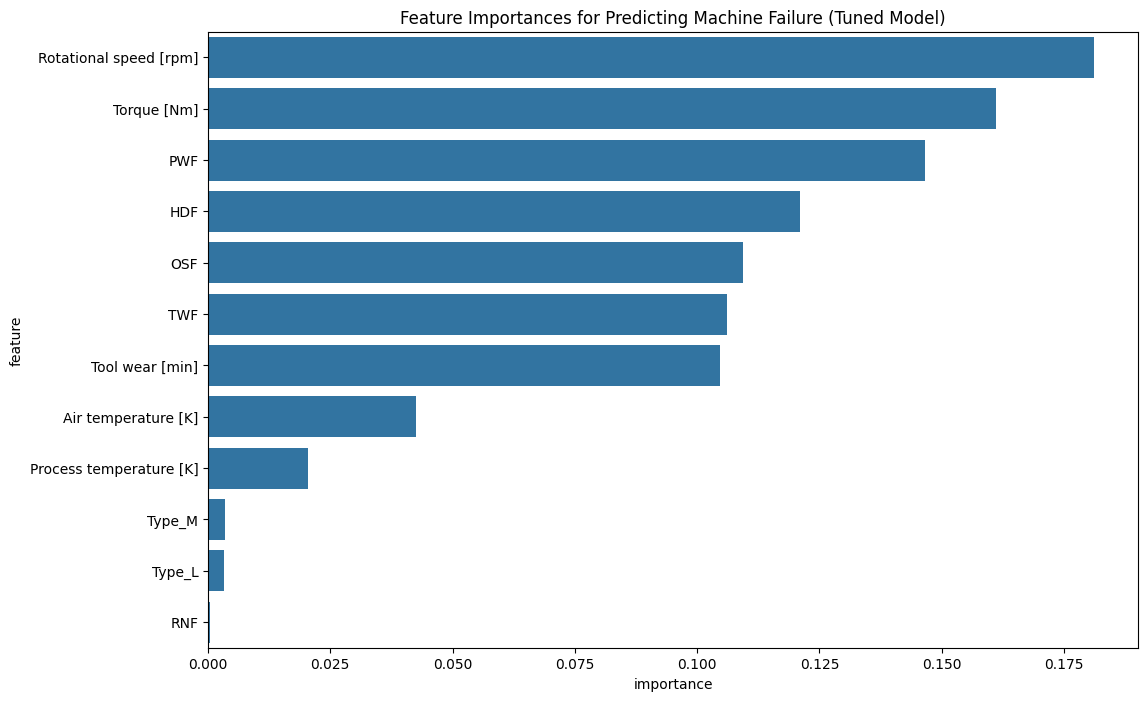

In [12]:
feature_importances = pd.DataFrame({'feature': X.columns, 'importance': best_model.feature_importances_})
feature_importances = feature_importances.sort_values('importance', ascending=False).reset_index(drop=True)

print("고장 예측에 중요한 변수 Top 5:")
print(feature_importances.head())

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importances)
plt.title('Feature Importances for Predicting Machine Failure (Tuned Model)')
plt.show()

## 8. 결론 및 향후 방향
기본 RandomForest 모델은 약 82%의 고장 재현율(recall)을 보였으며, 하이퍼파라미터 튜닝을 통해 이를 개선하는 과정을 진행했습니다. (실제 튜닝 결과에 따라 재현율이 달라질 수 있습니다.)
피처 중요도 분석 결과, `Torque`와 `Rotational speed`가 고장 예측의 핵심 요인임을 재확인했습니다.
### 향후 방향
- **다른 모델과 비교**: `XGBoost`, `LightGBM`과 같은 부스팅 계열 모델과 성능을 비교하여 최적의 모델을 선정할 수 있습니다.
- **피처 엔지니어링**: 기존 변수들을 조합하여 새로운 파생 변수(예: '온도 차이', '동력')를 만들어 모델 성능을 향상시킬 수 있습니다.
- **실시간 스트리밍 데이터 처리**: 실제 현장 적용을 위해 Kafka와 같은 스트리밍 플랫폼에서 들어오는 데이터를 실시간으로 처리하고 예측하는 아키텍처를 구상해볼 수 있습니다.